### Normalization

Normalization means changing the scale of data so that different features are on a similar range.

Type of Normalization :
- 1. Min-Max Normalization
- 2. Z-Score Standardization
- 3. 3. Robust Scaling

**1. Min-Max Normalization**

Changes values to a fixed range, usually 0 to 1.
```python
Formula:
x' = (x - min) / (max - min)
```

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("../../data/wine_data.csv", header= None, usecols=[0,1,2])
df.columns = ["Class label","Alcohal", "Malic acid"]
df.head()

,Class label,Alcohal,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


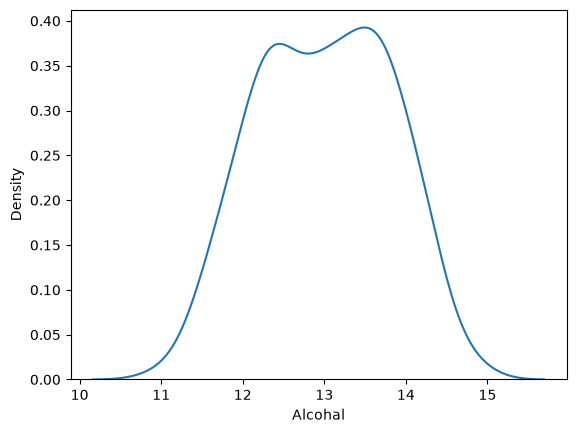

In [18]:
sns.kdeplot(df["Alcohal"]);

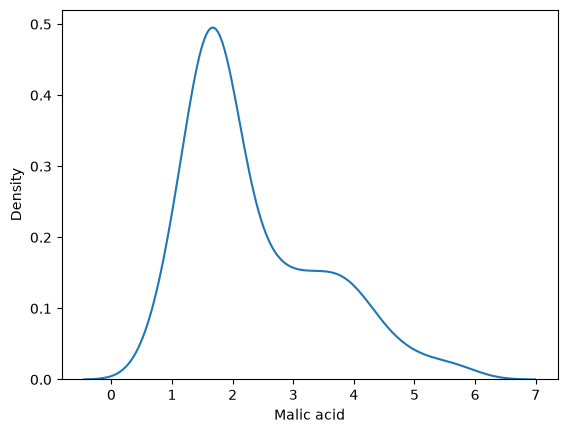

In [20]:
sns.kdeplot(df["Malic acid"]);

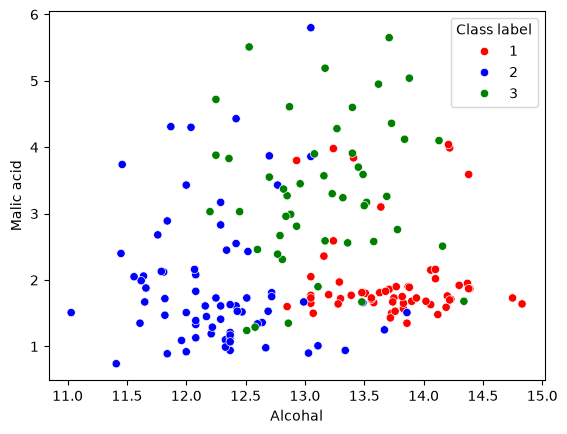

In [27]:
color_dict = {1: 'red', 3: 'green', 2: 'blue'}

sns.scatterplot(
    x=df['Alcohal'],
    y=df['Malic acid'],
    hue=df['Class label'],
    palette=color_dict
);

In [56]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=0)
X_train.shape, X_test.shape, y_test.shape, y_train.shape

((124, 2), (54, 2), (54,), (124,))

In [59]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the paramters
scaler.fit(X_train)

# transform train and test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
X_train_scaled[:5]

array([[0.72043011, 0.20378151],
       [0.31989247, 0.08403361],
       [0.60215054, 0.71218487],
       [0.57258065, 0.56302521],
       [0.76075269, 0.1302521 ]])

In [61]:
X_train_scaled = pd.DataFrame(data=X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(data=X_test_scaled, columns=X_test.columns)

In [62]:
(X_train_scaled.describe()).round(2)

,Alcohal,Malic acid
count,124.00,124.00
mean,0.53,0.31
std,0.22,0.24
min,0.00,0.00
25%,0.36,0.15
50%,0.54,0.21
75%,0.70,0.50
max,1.00,1.00


In [63]:
(X_test_scaled.describe()).round(2)

,Alcohal,Malic acid
count,54.00,54.00
mean,0.54,0.28
std,0.23,0.23
min,0.10,-0.03
25%,0.36,0.15
50%,0.54,0.18
75%,0.72,0.38
max,1.02,1.03


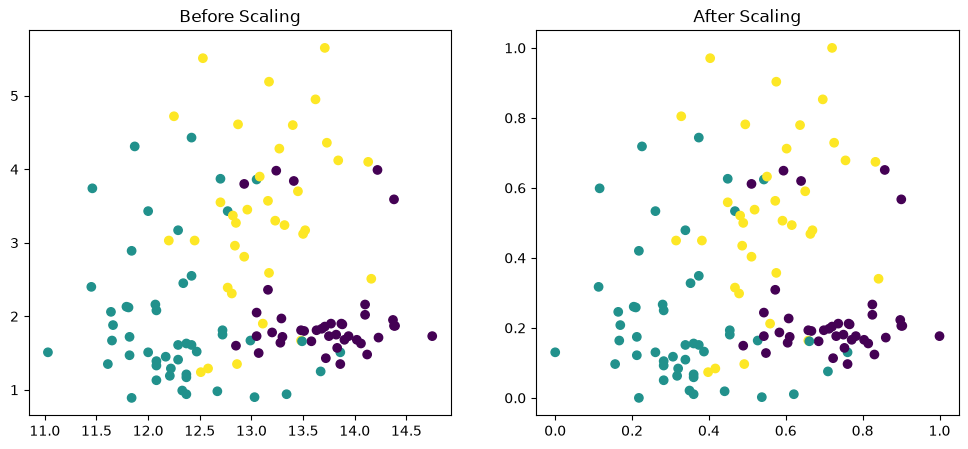

In [64]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(
    x=X_train["Alcohal"],
    y=X_train['Malic acid'],
    c=y_train
)
ax1.set_title("Before Scaling")

ax2.scatter(
    x=X_train_scaled["Alcohal"],
    y=X_train_scaled['Malic acid'],
    c=y_train
)
ax2.set_title("After Scaling")

plt.show()

In [68]:
df.columns

Index(['Class label', 'Alcohal', 'Malic acid'], dtype='str')

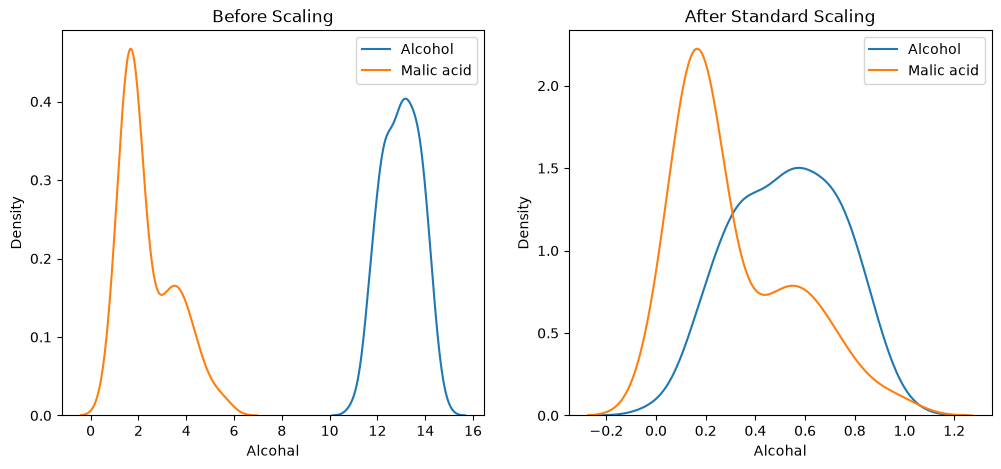

In [69]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohal'], ax=ax1, label='Alcohol')
sns.kdeplot(X_train['Malic acid'], ax=ax1, label='Malic acid')
ax1.legend()

ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohal'], ax=ax2, label='Alcohol')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2, label='Malic acid')
ax2.legend()

plt.show()

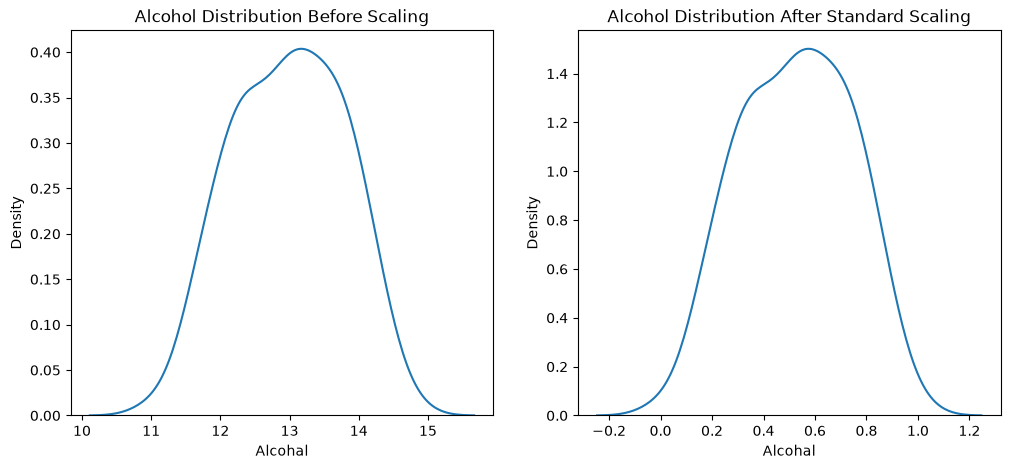

In [71]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohal'], ax=ax1)

# After scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohal'], ax=ax2)

plt.show()

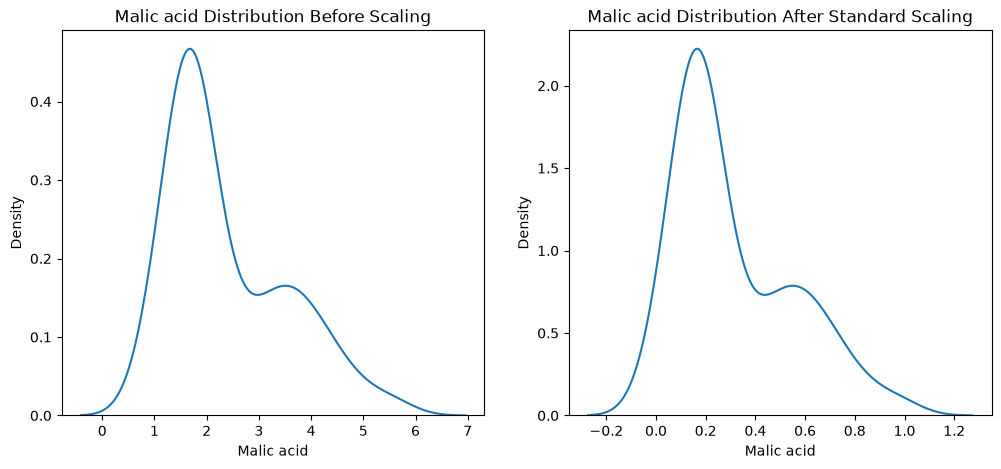

In [72]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

**2.Mean Normalization**

Mean normalization means subtracting the mean from each value and scaling it by the range.
```python
Formula
x' = (x - mean) / (max - min)
```
Mean normalization = center the data around 0 and scale it based on the range.

**3. Max Absolute Scaling**

Max Absolute Scaling means dividing every value by the largest absolute value in that feature.
```python
Formula
x' = x / max(|x|)
```
It is useful when your data contains both positive and negative values and you want to preserve sparsity.

In [73]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X)

**4.Robust Scaling**

Robust Scaling means scaling data using the median and IQR instead of the mean and standard deviation.

It is called "robust" because it is less affected by outliers.

```python 
Formula
x' = (x - median) / IQR
IQR = Q3 - Q1
```

In [74]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

df = pd.DataFrame({
    'age': [20, 22, 25, 30, 100],
    'salary': [20000, 25000, 30000, 35000, 500000]
})

scaler = RobustScaler()

X_scaled = scaler.fit_transform(df)

print(X_scaled)

[[-0.625 -1.   ]
 [-0.375 -0.5  ]
 [ 0.     0.   ]
 [ 0.625  0.5  ]
 [ 9.375 47.   ]]
